In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [2]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
device

device(type='cuda')

### Downloading APPLE stock details from 2020 to present

In [4]:
ticker='AAPL'
df=yf.download(ticker,'2020-01-01')

[*********************100%***********************]  1 of 1 completed


In [5]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200
...,...,...,...,...,...
2026-07-27,336.910004,339.570007,334.019989,334.540009,49604300
2026-07-28,340.079987,342.890015,335.600006,340.029999,51859000


<Axes: xlabel='Date'>

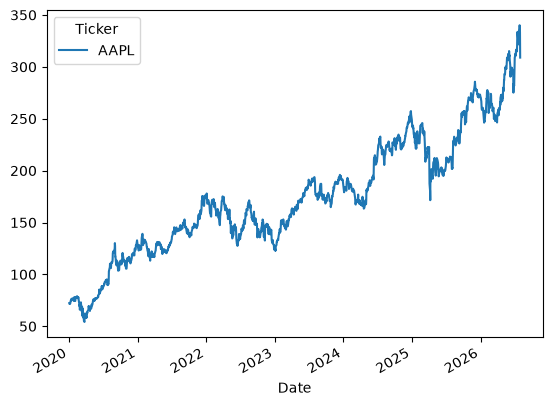

In [6]:
df['Close'].plot()

In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_data=scaler.fit_transform((df['Close']))

### Sequence length: For every 29 days in train we need to predict the stock price of the 30th day

In [8]:
seq_len=30
data=[]
for i in range(len(df)-seq_len):
    data.append(scaled_data[i:i+seq_len])

data=np.array(data)
data

array([[[-1.76353116],
        [-1.77563461],
        [-1.76581108],
        ...,
        [-1.68055554],
        [-1.64902053],
        [-1.65870106]],

       [[-1.77563461],
        [-1.76581108],
        [-1.77165554],
        ...,
        [-1.64902053],
        [-1.65870106],
        [-1.65836885]],

       [[-1.76581108],
        [-1.77165554],
        [-1.75175992],
        ...,
        [-1.65870106],
        [-1.65836885],
        [-1.68309021]],

       ...,

       [[ 2.09321305],
        [ 2.14174764],
        [ 2.08512386],
        ...,
        [ 2.72313488],
        [ 2.79008588],
        [ 2.84464443]],

       [[ 2.14174764],
        [ 2.08512386],
        [ 2.12057846],
        ...,
        [ 2.79008588],
        [ 2.84464443],
        [ 2.81211593]],

       [[ 2.08512386],
        [ 2.12057846],
        [ 2.10336747],
        ...,
        [ 2.84464443],
        [ 2.81211593],
        [ 2.73019145]]], shape=(1623, 30, 1))

### Converting training and Testing Data to Tensor and on cuda

In [9]:
train_size=int(0.8*len(data))
X_train=torch.from_numpy(data[:train_size,:-1,:]).type(torch.Tensor).to(device)
y_train=torch.from_numpy(data[:train_size,-1,:]).type(torch.Tensor).to(device)
X_test=torch.from_numpy(data[train_size:,:-1,:]).type(torch.Tensor).to(device)
y_test=torch.from_numpy(data[train_size:,-1,:]).type(torch.Tensor).to(device)

In [10]:
y_train

tensor([[-1.6587],
        [-1.6584],
        [-1.6831],
        ...,
        [ 0.3959],
        [ 0.2516],
        [ 0.3840]], device='cuda:0')

# Model Definition

This model can be used as a model for optuna tuned also

In [11]:
class PredictionModel(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers,
        output_size,
        ##dropout
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
           ##dropout=dropout if num_layers > 1 else 0

        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
           ## nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.ReLU(),
           ## nn.Dropout(dropout),
            nn.Linear(hidden_size // 4, output_size)
        )

    def forward(self, x):
        out, _ = self.lstm(x)

        # Last timestep output
        out = out[:, -1, :]

        out = self.fc(out)

        return out

## Dagshub: To Track parameters using MLflow

In [12]:
import dagshub

dagshub.init(
    repo_owner="astitvamishra0393",
    repo_name="Stock_price_LSTM",
    mlflow=True
)

import os
os.environ["MLFLOW_TRACKING_USERNAME"] = "astitvamishra0393"

os.environ["MLFLOW_TRACKING_PASSWORD"] = "3bd956ae7246a89b696cac2a748b5de5b16083a1"

Accessing as astitvamishra0393

Initialized MLflow to track repo "astitvamishra0393/Stock_price_LSTM"

Repository astitvamishra0393/Stock_price_LSTM initialized!

## Base Model

In [13]:
# Baseline hyperparameters

input_size = X_train.shape[2]
input_size=1
hidden_size = 32
num_layers = 2
output_size = 1

learning_rate = 0.001
epochs = 200
optimizer_name = "Adam"

In [14]:
model=PredictionModel(input_size=input_size,hidden_size=hidden_size,num_layers=num_layers,output_size=output_size).to(device)

## Setting MLFlow url to connect it via dagshub

In [15]:
import mlflow
mlflow.set_tracking_uri("https://dagshub.com/astitvamishra0393/Stock_price_LSTM.mlflow")

mlflow.set_experiment(
    "Stock_Prediction_LSTM"
)

<Experiment: artifact_location='mlflow-artifacts:/a7959eba3aa34362b10d8ba66fbd544f', creation_time=1785525045317, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1785525045317, lifecycle_stage='active', name='Stock_Prediction_LSTM', tags={}, trace_location=None, workspace='default'>

In [16]:
import torch.optim as optim
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)
from sklearn.metrics import root_mean_squared_error,mean_squared_error

### Running the baseline model

#### In this step we follow the following steps:
###### 1)start mlflow run
###### 2)log_parameters:MLflow
###### 3)Training Loop
###### 4)Log Train Loss:MLflow
###### 5)Testing Loop
###### 6)Log Test loss:MLflow
###### 7)Inverse scaling: To get the final prediction not in standard format but close to value
###### 8)RMSE: Train and Test RMSE
###### 9)Plotting figures for EDA
###### 10)Logging figure as an artifact in MLflow
###### 11)Logging Model

Epoch [0/200] Loss: 0.581084
Epoch [20/200] Loss: 0.031630
Epoch [40/200] Loss: 0.005302
Epoch [60/200] Loss: 0.004248
Epoch [80/200] Loss: 0.003725
Epoch [100/200] Loss: 0.003370
Epoch [120/200] Loss: 0.003127
Epoch [140/200] Loss: 0.002944
Epoch [160/200] Loss: 0.002806
Epoch [180/200] Loss: 0.002707
Test Loss: 0.014147
Train RMSE: 2.9860
Test RMSE: 6.9109


2026/08/02 13:17:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/02 13:17:51 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/08/02 13:17:51 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/08/02 13:18:00 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label

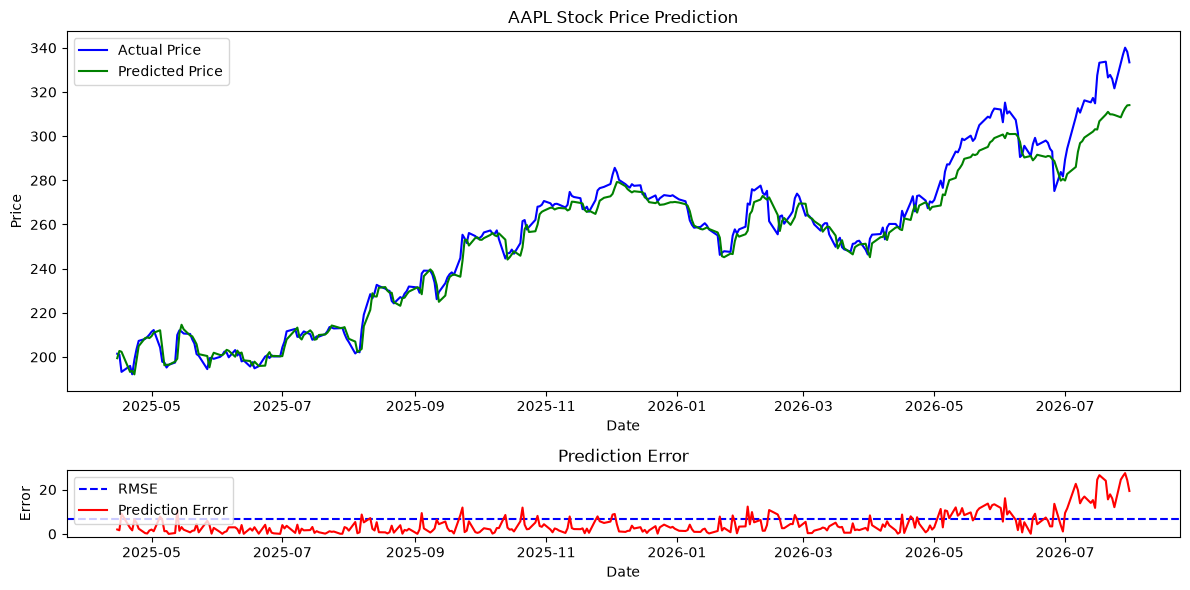

🏃 View run Baseline_LSTM at: https://dagshub.com/astitvamishra0393/Stock_price_LSTM.mlflow/#/experiments/0/runs/5ef6d08aaa30439ab75f24970aa99ebd
🧪 View experiment at: https://dagshub.com/astitvamishra0393/Stock_price_LSTM.mlflow/#/experiments/0


In [17]:
with mlflow.start_run(run_name="Baseline_LSTM"):

    # =========================
    # Log Parameters
    # =========================

    mlflow.log_params({
        "model": "LSTM",
        "hidden_size": hidden_size,
        "num_layers": num_layers,
        "learning_rate": learning_rate,
        "epochs": epochs,
        "optimizer": "Adam",
        "loss_function": "MSELoss"
    })

    # =========================
    # Training
    # =========================

    for epoch in range(epochs):

        model.train()

        optimizer.zero_grad()

        y_train_pred = model(X_train)

        loss = criterion(
            y_train_pred,
            y_train
        )

        loss.backward()

        optimizer.step()

        if epoch % 20 == 0:
            print(
                f"Epoch [{epoch}/{epochs}] "
                f"Loss: {loss.item():.6f}"
            )

    # Final training loss

    mlflow.log_metric(
        "train_loss",
        loss.item()
    )

    # =========================
    # Testing
    # =========================

    model.eval()

    with torch.no_grad():

        y_test_pred = model(X_test)

        test_loss = criterion(
            y_test_pred,
            y_test
        )

    print(
        f"Test Loss: {test_loss.item():.6f}"
    )

    mlflow.log_metric(
        "test_loss",
        test_loss.item()
    )

    # =========================
    # Inverse Scaling
    # =========================

    y_train_pred_np = scaler.inverse_transform(
        y_train_pred.detach().cpu().numpy()
    )

    y_test_pred_np = scaler.inverse_transform(
        y_test_pred.detach().cpu().numpy()
    )

    y_train_actual = scaler.inverse_transform(
        y_train.detach().cpu().numpy()
    )

    y_test_actual = scaler.inverse_transform(
        y_test.detach().cpu().numpy()
    )

    # =========================
    # RMSE
    # =========================

    train_rmse = root_mean_squared_error(
        y_train_actual[:, 0],
        y_train_pred_np[:, 0]
    )

    test_rmse = root_mean_squared_error(
        y_test_actual[:, 0],
        y_test_pred_np[:, 0]
    )

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")

    mlflow.log_metric(
        "train_rmse",
        train_rmse
    )

    mlflow.log_metric(
        "test_rmse",
        test_rmse
    )

    # =========================
    # Prediction Plot
    # =========================

    figure = plt.figure(figsize=(12, 6))

    gs = figure.add_gridspec(4, 1)

    # Price Plot
    ax1 = figure.add_subplot(gs[:3, 0])

    ax1.plot(
        df.iloc[-len(y_test_actual):].index,
        y_test_actual,
        color="blue",
        label="Actual Price"
    )

    ax1.plot(
        df.iloc[-len(y_test_actual):].index,
        y_test_pred_np,
        color="green",
        label="Predicted Price"
    )

    ax1.set_title(
        f"{ticker} Stock Price Prediction"
    )

    ax1.set_xlabel("Date")
    ax1.set_ylabel("Price")
    ax1.legend()

    # Error Plot
    ax2 = figure.add_subplot(gs[3, 0])

    ax2.axhline(
        test_rmse,
        color="blue",
        linestyle="--",
        label="RMSE"
    )

    ax2.plot(
        df.iloc[-len(y_test_actual):].index,
        abs(
            y_test_actual.flatten()
            - y_test_pred_np.flatten()
        ),
        color="red",
        label="Prediction Error"
    )

    ax2.set_title("Prediction Error")
    ax2.set_xlabel("Date")
    ax2.set_ylabel("Error")
    ax2.legend()

    plt.tight_layout()

    # =========================
    # Log Figure
    # =========================

    mlflow.log_figure(
        figure,
        "baseline_prediction.png"
    )

    # =========================
    # Save Model
    # =========================

    mlflow.pytorch.log_model(
        model,
        "baseline_model",
        serialization_format="pickle"
    )

    plt.show()

    mlflow.log_artifact("lstm_model.pth")
    mlflow.log_artifact("scaler.pkl")
    mlflow.log_artifact("config.json")

## Dumping Baseline Model

In [43]:
import json
import pickle
import os

# Create directory for saved model
model_dir = "stock_price_model"
os.makedirs(model_dir, exist_ok=True)

print("Saving baseline model...")
print("="*70)

# ========== SAVE MODEL WEIGHTS ==========
model_path = os.path.join(model_dir, "model.pth")
torch.save(model.state_dict(), model_path)
print(f"✓ Model weights saved: {model_path}")

# ========== SAVE SCALER ==========
scaler_path = os.path.join(model_dir, "scaler.pkl")
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Scaler saved: {scaler_path}")

# ========== SAVE CONFIGURATION ==========
config = {
    "input_size": 1,
    "hidden_size": 32,           # From your model definition
    "num_layers": 2,             # From your model definition
    "output_size": 1,
    "seq_len": 30,               # Sequence length used in data prep
    "ticker": "AAPL",            # Stock ticker
    "model_type": "LSTM",
    "training_date": str(pd.Timestamp.now()),
    "description": "Baseline LSTM model for stock price prediction"
}

config_path = os.path.join(model_dir, "config.json")
with open(config_path, 'w') as f:
    json.dump(config, f, indent=4)
print(f"✓ Config saved: {config_path}")

# ========== SUMMARY ==========
print("\n" + "="*70)
print("✓ MODEL SAVED SUCCESSFULLY!")
print("="*70)
print(f"\nFiles created:")
print(f"  1. {model_path}")
print(f"  2. {scaler_path}")
print(f"  3. {config_path}")
print(f"\nDirectory structure:")
print(f"  {model_dir}/")
print(f"  ├── model.pth")
print(f"  ├── scaler.pkl")
print(f"  └── config.json")
print("\n✓ Ready for FastAPI deployment!")
print("="*70)

Saving baseline model...
✓ Model weights saved: stock_price_model\model.pth
✓ Scaler saved: stock_price_model\scaler.pkl
✓ Config saved: stock_price_model\config.json

✓ MODEL SAVED SUCCESSFULLY!

Files created:
  1. stock_price_model\model.pth
  2. stock_price_model\scaler.pkl
  3. stock_price_model\config.json

Directory structure:
  stock_price_model/
  ├── model.pth
  ├── scaler.pkl
  └── config.json

✓ Ready for FastAPI deployment!


In [44]:
print("\nVerifying saved files...")

# Check file sizes
for file in ["model.pth", "scaler.pkl", "config.json"]:
    file_path = os.path.join(model_dir, file)
    if os.path.exists(file_path):
        size = os.path.getsize(file_path)
        print(f"  ✓ {file}: {size:,} bytes")
    else:
        print(f"  ✗ {file}: NOT FOUND")

# Load and verify config
with open(config_path, 'r') as f:
    loaded_config = json.load(f)
print(f"\n✓ Config loaded successfully:")
for key, value in loaded_config.items():
    print(f"  - {key}: {value}")

print("\n" + "="*70)
print("✓ ALL FILES VERIFIED - READY TO DEPLOY!")
print("="*70)



Verifying saved files...
  ✓ model.pth: 58,039 bytes
  ✓ scaler.pkl: 533 bytes
  ✓ config.json: 286 bytes

✓ Config loaded successfully:
  - input_size: 1
  - hidden_size: 32
  - num_layers: 2
  - output_size: 1
  - seq_len: 30
  - ticker: AAPL
  - model_type: LSTM
  - training_date: 2026-08-02 18:43:02.295476
  - description: Baseline LSTM model for stock price prediction

✓ ALL FILES VERIFIED - READY TO DEPLOY!


In [18]:
# import mlflow

# run_ids = [
#     "6143ff53893a460a9beb511e7b8fab49",
#     "166ef4189538403c8a6340d443075e27",
#     "b8282fe98c62451fa1dd1f166106ede6",
#     "f8a7b77ce6354acf911ea39e79266798",
#     "a27dec4f05c64499b5bebe1a38286d09",
#     "5d1d8240434d425092404067caebd57b",
#     "3a2da2437c9f49d59e43a4722090d590"
# ]

# for run_id in run_ids:
#     mlflow.delete_run(run_id)

# print("Runs deleted successfully")

## Optimized Model: Model-1o-v1

#### Tuning Hyperparametes using Optuna to get more optimized and effiecient Model

In [19]:
import optuna as optuna

### Creating train,val and test set: 70,15,15

Note that the Model Definition will be the same throughout all models

In [20]:
# CELL 31 - CORRECTED DATA SPLIT

train_size_opt = int(0.70 * len(data))
val_size_opt = int(0.15 * len(data))

X_train_opt = torch.from_numpy(data[:train_size_opt, :-1, :]).type(torch.Tensor).to(device)
y_train_opt = torch.from_numpy(data[:train_size_opt, -1, :]).type(torch.Tensor).to(device)  # ✅ Fixed: train_size_opt

X_val = torch.from_numpy(data[train_size_opt:train_size_opt+val_size_opt, :-1, :]).type(torch.Tensor).to(device)  # ✅ Fixed: train_size_opt+val_size_opt
y_val = torch.from_numpy(data[train_size_opt:train_size_opt+val_size_opt, -1, :]).type(torch.Tensor).to(device)

X_test_opt = torch.from_numpy(data[train_size_opt+val_size_opt:, :-1, :]).type(torch.Tensor).to(device)
y_test_opt = torch.from_numpy(data[train_size_opt+val_size_opt:, -1, :]).type(torch.Tensor).to(device)


In [21]:
from torch.utils.data import TensorDataset, DataLoader

In [31]:
def objective(trial):
    hidden_size=trial.suggest_int(
        "hidden_size",
        16,64,
        step=32
    )
    num_layers=trial.suggest_int(
        "num_layers",
        1,2
    )
    learning_rate = trial.suggest_loguniform(
        "learning_rate", 
        1e-5, 1e-3
    )
    batch_size = trial.suggest_categorical(
        "batch_size", 
        [16, 32, 64]
    )
    epochs = trial.suggest_int(
        "epochs", 
        50, 200, 
        step=50)
    trial_model=PredictionModel(
        input_size=1,
        hidden_size=hidden_size,
        num_layers=num_layers,
        output_size=1
    ).to(device)
    optimizer=torch.optim.Adam(trial_model.parameters(),lr=learning_rate,weight_decay=1e-5)
    criterion=nn.MSELoss()
    train_dataset=TensorDataset(X_train_opt,y_train_opt)
    train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
    val_dataset=TensorDataset(X_val,y_val)
    val_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
    
    best_val_loss = float('inf')
    patience = 20
    patience_counter = 0
    
    for epoch in range(epochs):
        
        # Training Phase
        trial_model.train()
        train_loss = 0
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = trial_model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        # Validation Phase
        trial_model.eval()
        val_loss = 0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_pred = trial_model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        
        # Early Stopping Logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break
        
        # Report to Optuna for pruning
        trial.report(val_loss, epoch)
        
        # Optuna: Check if trial should be pruned
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return best_val_loss


In [32]:
def log_trial_mlflow(study,trial):
    with mlflow.start_run(run_name=f"Trial_{trial.number}"):
        # Log all hyperparameters
        mlflow.log_params(trial.params)
        
        # Log the validation loss (objective value)
        mlflow.log_metric("best_val_loss", trial.value)
        mlflow.log_metric("trial_number", trial.number)
        
        # Log trial state
        mlflow.log_param("trial_state", str(trial.state))


In [33]:
mlflow.set_experiment("Stock_Prediction_Optuna_Optimization")
sampler = optuna.samplers.TPESampler(seed=42)
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)

study = optuna.create_study(
    direction='minimize',  # Minimize validation loss
    sampler=sampler,
    pruner=pruner
)

# Number of trials for hyperparameter search
n_trials = 20

print("="*70) 
print("STARTING OPTUNA HYPERPARAMETER OPTIMIZATION")
print("="*70)
print(f"Number of trials: {n_trials}")
print(f"Hyperparameters to tune: hidden_size, num_layers, learning_rate, batch_size, epochs")
print("="*70 + "\n")

# Run optimization
study.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[log_trial_mlflow],
    show_progress_bar=True
)


[I 2026-08-02 18:01:51,673] A new study created in memory with name: no-name-5d75802c-e6ac-4d74-b934-c44ba0bba990


STARTING OPTUNA HYPERPARAMETER OPTIMIZATION
Number of trials: 20
Hyperparameters to tune: hidden_size, num_layers, learning_rate, batch_size, epochs



  0%|          | 0/20 [00:00<?, ?it/s]

C:\Users\ASTITVA MISHRA\AppData\Local\Temp\ipykernel_38832\4082755432.py:2: UserWarning: The distribution is specified by [16, 64] and step=32, but the range is not divisible by `step`. It will be replaced with [16, 48].
  hidden_size=trial.suggest_int(
C:\Users\ASTITVA MISHRA\AppData\Local\Temp\ipykernel_38832\4082755432.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform(


[I 2026-08-02 18:02:04,009] Trial 0 finished with value: 0.0034886101936318086 and parameters: {'hidden_size': 16, 'num_layers': 2, 'learning_rate': 0.000291063591313307, 'batch_size': 16, 'epochs': 50}. Best is trial 0 with value: 0.0034886101936318086.
🏃 View run Trial_0 at: https://dagshub.com/astitvamishra0393/Stock_price_LSTM.mlflow/#/experiments/1/runs/8fe6d4096a124d9a93e7cee7021a3254
🧪 View experiment at: https://dagshub.com/astitvamishra0393/Stock_price_LSTM.mlflow/#/experiments/1
[I 2026-08-02 18:02:13,401] Trial 1 finished with value: 0.003905818112091058 and parameters: {'hidden_size': 48, 'num_layers': 2, 'learning_rate': 0.0002607024758370766, 'batch_size': 32, 'epochs': 50}. Best is trial 0 with value: 0.0034886101936318086.
🏃 View run Trial_1 at: https://dagshub.com/astitvamishra0393/Stock_price_LSTM.mlflow/#/experiments/1/runs/1f9b70f2ffe749ed900f89b918b30d58
🧪 View experiment at: https://dagshub.com/astitvamishra0393/Stock_price_LSTM.mlflow/#/experiments/1
[I 2026-08-0

In [34]:
best_trial = study.best_trial
print(f"Best Validation Loss: {best_trial.value:.6f}")
print(f"\nBest Hyperparameters:")
for param, value in best_trial.params.items():
    print(f"  • {param}: {value}")


Best Validation Loss: 0.002121

Best Hyperparameters:
  • hidden_size: 48
  • num_layers: 2
  • learning_rate: 0.0009950856672150351
  • batch_size: 64
  • epochs: 100


In [35]:
best_params=best_trial.params
print("Trainig optunized Model with best Hyperparameters")
print("="*70)
with mlflow.start_run(run_name="Model-1o-v1"):
    ## LOG BEST PARAMS
    mlflow.log_params(best_params)
    mlflow.log_param("Optimization_Method","Optuna")
    mlflow.log_param("total_trials",n_trials)
    mlflow.log_metric("Best_trial_validation_loss",best_trial.value)

    ##FINAL MODEL
    final_model=PredictionModel(
        input_size=1,
        hidden_size=best_params['hidden_size'],
        num_layers=best_params['num_layers'],
        output_size=1
    ).to(device)

    print("Model Architechure\n")
    print(f"Hidden Size:{best_params['hidden_size']}\n")
    print(f"  Number of Layers: {best_params['num_layers']}")
    print(f"  Output Size: 1\n")

    ##TRAINING SETUP
    optimizer=torch.optim.Adam(final_model.parameters(),lr=best_params['learning_rate'])
    criterion=nn.MSELoss()

    train_dataset=TensorDataset(X_train_opt,y_train_opt)
    train_loader=DataLoader(
        train_dataset,
        batch_size=best_params['batch_size'],
        shuffle=True
    )
    val_dataset = TensorDataset(X_val, y_val)
    val_loader = DataLoader(
        val_dataset, 
        batch_size=best_params['batch_size'], 
        shuffle=False
    )

    ##TRAINING LOOP
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    epochs = best_params['epochs']
    for epoch in range(epochs):
        final_model.train()
        train_loss=0
        for X_batch,y_batch in train_loader:
            optimizer.zero_grad()
            y_pred=final_model(X_batch)
            loss=criterion(y_pred,y_batch)
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()
        train_loss/=len(train_loader)
        train_losses.append(train_loss)

    #Validation Phase
        final_model.eval()
        val_loss=0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_pred = final_model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        # Track best validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
        
        # Print progress
        if epoch % 20 == 0 or epoch == epochs - 1:
            print(f"  Epoch [{epoch:3d}/{epochs-1}] | "
                  f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
        
        # Log metrics to MLflow
        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("val_loss", val_loss, step=epoch) 

    print(f"Best Val loss:{best_val_loss:.6f}")
        
    print("Evaluating on Test Set")
    final_model.eval()

    with torch.no_grad():
        y_test_pred = final_model(X_test)
        test_loss = criterion(y_test_pred, y_test)
        
        # Validation predictions (for comparison)
        y_val_pred = final_model(X_val)
        
        # Training predictions
        y_train_pred_full = final_model(X_train)
    
    print(f"Test Loss (MSE): {test_loss.item():.6f}")
    
    mlflow.log_metric("test_loss", test_loss.item())
    
    # === INVERSE SCALING ===
    y_train_pred_np = scaler.inverse_transform(y_train_pred_full.detach().cpu().numpy())
    y_train_actual = scaler.inverse_transform(y_train.detach().cpu().numpy())
    
    y_val_pred_np = scaler.inverse_transform(y_val_pred.detach().cpu().numpy())
    y_val_actual = scaler.inverse_transform(y_val.detach().cpu().numpy())
    
    y_test_pred_np = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
    y_test_actual = scaler.inverse_transform(y_test.detach().cpu().numpy())    

Trainig optunized Model with best Hyperparameters
Model Architechure

Hidden Size:48

  Number of Layers: 2
  Output Size: 1

  Epoch [  0/99] | Train Loss: 0.421631 | Val Loss: 1.285347
  Epoch [ 20/99] | Train Loss: 0.005235 | Val Loss: 0.025161
  Epoch [ 40/99] | Train Loss: 0.003294 | Val Loss: 0.013001
  Epoch [ 60/99] | Train Loss: 0.002747 | Val Loss: 0.011353
  Epoch [ 80/99] | Train Loss: 0.002513 | Val Loss: 0.009128
  Epoch [ 99/99] | Train Loss: 0.002332 | Val Loss: 0.014125
Best Val loss:0.008289
Evaluating on Test Set
Test Loss (MSE): 0.213808
🏃 View run Model-1o-v1 at: https://dagshub.com/astitvamishra0393/Stock_price_LSTM.mlflow/#/experiments/1/runs/417501b4a67944f08a8318d7bdd4e92c
🧪 View experiment at: https://dagshub.com/astitvamishra0393/Stock_price_LSTM.mlflow/#/experiments/1


In [37]:
## Since MSE is too large Model might be overfitting

## We will proceed with the BaseLine Model